# Clasificación de Tareas ARC según Hipótesis del Usuario

Este notebook clasifica las tareas del dataset ARC-AGI usando BERTopic sobre el texto de la **hipótesis final** emitida por cada usuario al resolver la tarea.

In [1]:
import json
import re
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-darkgrid')

/home/laureano-arcanio/ARC-AGI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga y Extracción de Datos

Extraemos el texto de la **hipótesis final** de cada intento (`attempt`) de cada usuario, priorizando:
1. `hypothesis_finalized` — la hipótesis confirmada por el usuario
2. Último `hypothesis_revision` — última revisión antes de finalizar
3. `initial_hypothesis` — hipótesis inicial como fallback

In [2]:
def extract_final_hypothesis(events):
    """Extrae la hipótesis final de una lista de eventos, priorizando hypothesis_finalized."""
    finalized = None
    last_revision = None
    initial = None

    for event in events:
        trigger = event.get('trigger', {})
        if trigger.get('kind') != 'cognitive':
            continue
        text = trigger.get('text', '').strip()
        if not text:
            continue
        intent = trigger.get('intent', '')
        if intent == 'hypothesis_finalized':
            finalized = text
        elif intent == 'hypothesis_revision':
            last_revision = text
        elif intent == 'initial_hypothesis':
            initial = text

    return finalized or last_revision or initial or ''


def clean_text(text):
    """Limpia el texto: une líneas, elimina exceso de espacios."""
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = re.sub(r'\s+', ' ', text).strip()
    return text


records = []
with open('arc-tasks-dataset.jsonl', 'r') as f:
    for line in f:
        d = json.loads(line)
        task_id = d['task_id']
        for user in d.get('users', []):
            user_id = user['user_id']
            email = user.get('email', '')
            for attempt in user.get('attempts', []):
                attempt_id = attempt['attempt_id']
                hypothesis = extract_final_hypothesis(attempt.get('events', []))
                if hypothesis:
                    records.append({
                        'task_id': task_id,
                        'user_id': user_id,
                        'email': email,
                        'attempt_id': attempt_id,
                        'hypothesis': clean_text(hypothesis),
                        'hypothesis_length': len(hypothesis),
                    })

df = pd.DataFrame(records)
print(f'Total de registros: {len(df)}')
print(f'Tareas únicas: {df["task_id"].nunique()}')
print(f'Usuarios únicos: {df["user_id"].nunique()}')
df.head(3)

Total de registros: 1120
Tareas únicas: 710
Usuarios únicos: 10


,task_id,user_id,email,attempt_id,hypothesis,hypothesis_length
0,009d5c81,3,tomaspalaciosgurtner2009@gmail.com,835,Se cambia el color de la figura más grande seg...,87
1,00dbd492,5,ger.simiana@gmail.com,889,Rellenar la pixeles negros de los cuadrados ro...,100
2,017c7c7b,12,larcanio@gmail.com,1030,dimension de entrada distinta a salida. la ent...,134


In [3]:
# Estadísticas de longitud de hipótesis
df['hypothesis_length'].describe()

count    1120.000000
mean      198.708036
std       146.843997
min        20.000000
25%        83.000000
50%       160.000000
75%       276.000000
max      1161.000000
Name: hypothesis_length, dtype: float64

In [4]:
# Mostrar algunos ejemplos de hipótesis
for i, row in df.sample(min(5, len(df)), random_state=42).iterrows():
    print(f"--- Task {row['task_id']} (User {row['user_id']}) ---")
    print(row['hypothesis'][:300])
    print()

--- Task 3d588dc9 (User 9) ---
A la figura negra que comparta al menos una fila de la matriz con la figura gris, se le saca sus dos pixeles negros por fuera del cuadrado principal y se pinta de rosa a la columna de la figura negra que esté más cercana a la figura gris.

--- Task 1e5d6875 (User 9) ---
Si en la entrada hay una figura gris que forma una "esquina", en la salida se añade la misma figura, pintada de amarillo, en el lado interior de la esquina. Si hay una esquina de color rojo, se añade a la misma figura, pintada de verde, en el lado exterior de la esquina.

--- Task db93a21d (User 3) ---
Se rebordea el cuadrado con una línea verde y se conectan al extremo con una línea azul

--- Task ed36ccf7 (User 3) ---
Se rota la figura 90 grados en sentido antihorario

--- Task 7fe24cdd (User 12) ---
la dimension de salida es dos veces la entrada. se copia tal cual el la entrada, luego se duplica en sentido orario, rotada 90 grados en cada una.



## 2. Modelado con BERTopic

Usamos BERTopic con un modelo de embeddings multilingüe (`paraphrase-multilingual-MiniLM-L12-v2`) para capturar el significado semántico de las hipótesis (escritas en español).

El pipeline de BERTopic:
1. **Embeddings** con SentenceTransformer
2. **Reducción de dimensionalidad** con UMAP
3. **Clustering** con HDBSCAN
4. **Extracción de tópicos** con c-TF-IDF

In [5]:
# Configurar modelo de embeddings multilingüe (español incluido)
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print(f'Dimension del embedding: {embedding_model.get_sentence_embedding_dimension()}')

# Extraer la lista de textos de hipótesis
hypotheses = df['hypothesis'].tolist()
print(f'Total de textos a procesar: {len(hypotheses)}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17829.80it/s]


Dimension del embedding: 384
Total de textos a procesar: 1120


In [6]:
# Configurar y ejecutar BERTopic
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42,
)

# Vectorizador con stopwords en español
vectorizer_model = CountVectorizer(
    stop_words=None,  # BERTopic usa stopwords multilingües internamente
    ngram_range=(1, 2),
    max_df=0.85,
    min_df=3,
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    vectorizer_model=vectorizer_model,
    language='multilingual',
    calculate_probabilities=False,
    verbose=True,
)

topics, probs = topic_model.fit_transform(hypotheses)

2026-07-17 12:15:12,585 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 35/35 [00:05<00:00,  6.56it/s]
2026-07-17 12:15:17,926 - BERTopic - Embedding - Completed ✓
2026-07-17 12:15:17,927 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-17 12:15:24,955 - BERTopic - Dimensionality - Completed ✓
2026-07-17 12:15:24,956 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-17 12:15:24,968 - BERTopic - Cluster - Completed ✓
2026-07-17 12:15:24,971 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-17 12:15:24,999 - BERTopic - Representation - Completed ✓


In [7]:
# Asignar el tópico a cada registro
df['topic'] = topics

# Ver distribución de tópicos
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,278,-1_forma_columna_color de_mas,"[forma, columna, color de, mas, las figuras, v...",[hay varios cuadrados de un color rodeados por...
1,0,281,0_la figura_celeste_patrón_las figuras,"[la figura, celeste, patrón, las figuras, los ...","[Se copia el patrón en la figura más grande, l..."
2,1,221,1_pixel_matriz_la matriz_los pixeles,"[pixel, matriz, la matriz, los pixeles, matriz...",[Se transforma a la matriz de entrada de la si...
3,2,88,2_dimension_dimension de_de entrada_igual la,"[dimension, dimension de, de entrada, igual la...",[la dimension de salida es distinta a la entra...
4,3,70,3_los cuadrados_de colores_del cuadrado_un cua...,"[los cuadrados, de colores, del cuadrado, un c...",[Dibujar un cuadrado cuyo tamaño lo indican lo...
5,4,52,4_las figuras_cada figura_los colores_la figura,"[las figuras, cada figura, los colores, la fig...",[Se intercambian los colores de las figuras de...
6,5,25,5_verde_pinta de_de verde_verde se,"[verde, pinta de, de verde, verde se, verdes, ...",[La linea creada por pixeles de color rojo fun...
7,6,22,6_negra_negro_la figura_rectángulo,"[negra, negro, la figura, rectángulo, negros, ...","[hacia donde apunta la figura gris , se encuen..."
8,7,20,7_la figura_figura de_el centro_3x3,"[la figura, figura de, el centro, 3x3, una fig...",[Hay figuras de colores que hacen caminos haci...
9,8,14,8_negros_negro_pixeles negros_la cantidad,"[negros, negro, pixeles negros, la cantidad, d...",[Hay cuadrados de colores con pixeles negros p...


## 3. Visualizaciones

Número de tópicos encontrados: 13


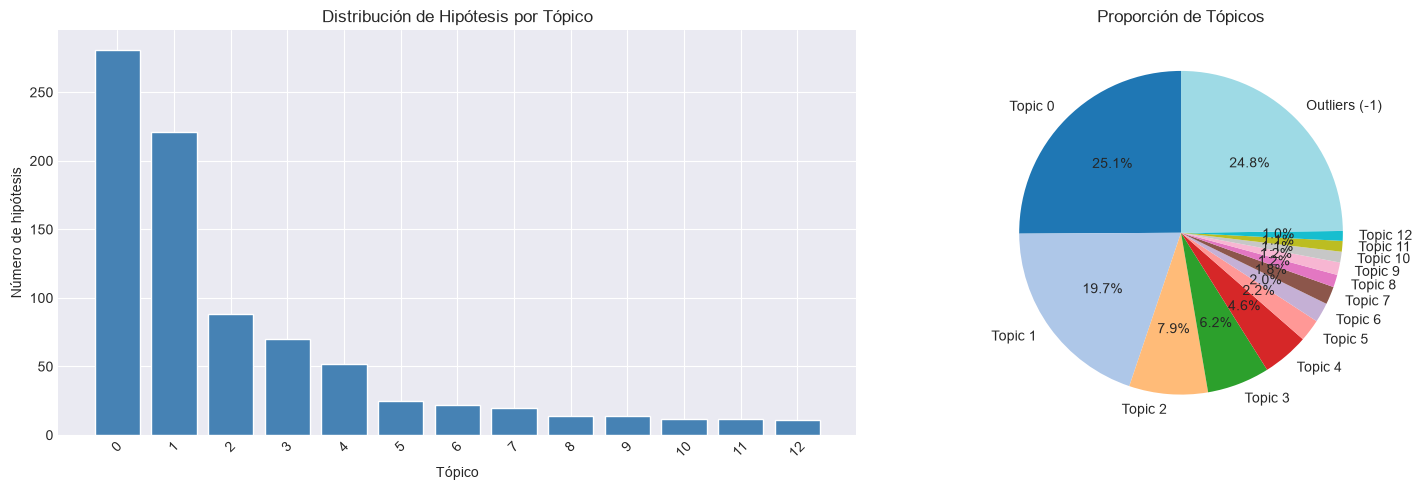

In [8]:
# Distribución de tópicos (excluyendo outliers = topic -1)
n_topics = len(topic_info[topic_info['Topic'] != -1])
print(f'Número de tópicos encontrados: {n_topics}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de barras
topic_counts = df[df['topic'] != -1]['topic'].value_counts().sort_index()
axes[0].bar(topic_counts.index.astype(str), topic_counts.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Tópico')
axes[0].set_ylabel('Número de hipótesis')
axes[0].set_title('Distribución de Hipótesis por Tópico')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
outlier_count = len(df[df['topic'] == -1])
labels = [f'Topic {t}' for t in topic_counts.index] + ['Outliers (-1)']
sizes = list(topic_counts.values) + [outlier_count]
colors = plt.cm.tab20(np.linspace(0, 1, len(labels)))
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporción de Tópicos')

plt.tight_layout()
plt.show()

In [9]:
# Visualización jerárquica (dendrograma)
fig = topic_model.visualize_hierarchy()
fig.update_layout(width=1000, height=700)
fig.show()

In [10]:
# Mapa de tópicos en 2D
fig = topic_model.visualize_topics()
fig.update_layout(width=1000, height=700)
fig.show()

In [11]:
# Heatmap de similitud entre tópicos
fig = topic_model.visualize_heatmap()
fig.update_layout(width=900, height=700)
fig.show()

In [12]:
# Palabras clave por tópico (bar chart)
if n_topics <= 12:
    try:
        fig = topic_model.visualize_barchart(top_n_topics=n_topics)
        fig.update_layout(width=1000, height=200 * n_topics)
        fig.show()
    except Exception:
        print('Bar chart visualization not available for these topics')
else:
    fig = topic_model.visualize_barchart(top_n_topics=12)
    fig.update_layout(width=1000, height=2400)
    fig.show()

## 4. Análisis Detallado por Tópico

Exploramos ejemplos de hipótesis y tareas representativas de cada tópico.

In [13]:
# Mostrar ejemplos de cada tópico (excluyendo outliers)
for topic_num in sorted(df[df['topic'] != -1]['topic'].unique()):
    topic_df = df[df['topic'] == topic_num]
    keywords = topic_model.get_topic(topic_num)
    keywords_str = ', '.join([w for w, _ in keywords[:10]])
    print(f'\n===== Tópico {topic_num} ({len(topic_df)} hipótesis) =====')
    print(f'Palabras clave: {keywords_str}')
    print(f'Tareas únicas: {topic_df["task_id"].nunique()}')
    print(f'Tareas ejemplo: {", ".join(topic_df["task_id"].unique()[:5])}')
    print('--- Hipótesis de ejemplo ---')
    for i, (_, row) in enumerate(topic_df.sample(min(3, len(topic_df)), random_state=42).iterrows()):
        print(f'  [{row["task_id"]}] {row["hypothesis"][:200]}')
    print()


===== Tópico 0 (281 hipótesis) =====
Palabras clave: la figura, celeste, patrón, las figuras, los cuadrados, el patrón, para, hasta, líneas, se copia
Tareas únicas: 240
Tareas ejemplo: 045e512c, 05a7bcf2, 0962bcdd, 0b17323b, 0bb8deee
--- Hipótesis de ejemplo ---
  [234bbc79] Se combinan las figuras para formar una linea
  [8d5021e8] Se copia la figura y se crea un patrón con ella, haciendo su espejo
  [e45ef808] Se aplica una línea roja bordó desde arriba hacia el punto más bajo de la montaña, y se aplica una línea desde arriba hacia el punto más alto de la misma montaña.


===== Tópico 1 (221 hipótesis) =====
Palabras clave: pixel, matriz, la matriz, los pixeles, matriz de, pixeles de, un pixel, mismo color, el pixel, columna
Tareas únicas: 161
Tareas ejemplo: 0607ce86, 0692e18c, 09c534e7, 0f63c0b9, 11dc524f
--- Hipótesis de ejemplo ---
  [9473c6fb] Se recorre la matriz para asignarle a cada pixel distinto de naranja un orden. Si hay más de un pixel distinto de naranja por columna, e

## 5. Matriz de Confusión: Tareas vs Tópicos

Analizamos cómo se distribuyen las hipótesis de una misma tarea entre distintos tópicos (una tarea puede tener múltiples usuarios/intentos con hipótesis clasificadas en diferentes tópicos).

In [14]:
# Para cada tarea, calcular el tópico más frecuente y la pureza
task_topic_info = []
for task_id, group in df[df['topic'] != -1].groupby('task_id'):
    dominant = group['topic'].value_counts()
    task_topic_info.append({
        'task_id': task_id,
        'dominant_topic': dominant.index[0],
        'dominant_count': dominant.iloc[0],
        'total_hypotheses': len(group),
        'n_unique_topics': group['topic'].nunique(),
        'purity': dominant.iloc[0] / len(group),
    })

task_topic_df = pd.DataFrame(task_topic_info)
print(f'Tareas con hipótesis clasificadas: {len(task_topic_df)}')
print(f'\nEstadísticas de pureza por tarea:')
task_topic_df['purity'].describe()

Tareas con hipótesis clasificadas: 581

Estadísticas de pureza por tarea:


count    581.000000
mean       0.941048
std        0.162118
min        0.285714
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: purity, dtype: float64

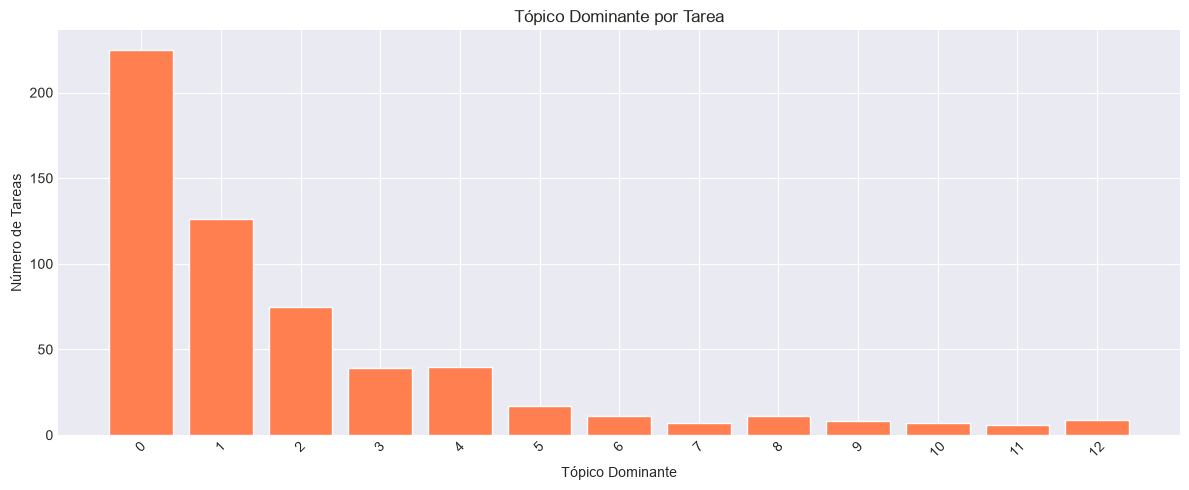

In [15]:
# Distribución del tópico dominante por tarea
dominant_dist = task_topic_df['dominant_topic'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(dominant_dist.index.astype(str), dominant_dist.values, color='coral', edgecolor='white')
ax.set_xlabel('Tópico Dominante')
ax.set_ylabel('Número de Tareas')
ax.set_title('Tópico Dominante por Tarea')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 6. Exportación de Resultados

In [16]:
# Exportar el DataFrame con tópicos asignados
export_df = df[['task_id', 'user_id', 'email', 'attempt_id', 'topic', 'hypothesis']].copy()
export_df.to_csv('arc_tasks_classified.csv', index=False)
print(f'Exportado a arc_tasks_classified.csv: {len(export_df)} registros')

# Exportar resumen de tópicos
topic_summary = topic_model.get_topic_info()
topic_summary.to_csv('arc_topics_summary.csv', index=False)
print(f'Exportado a arc_topics_summary.csv: {len(topic_summary)} tópicos')

Exportado a arc_tasks_classified.csv: 1120 registros
Exportado a arc_topics_summary.csv: 14 tópicos


## 7. Resumen Final

Clasificación de tareas ARC basada en las hipótesis textuales de los usuarios. Cada tópico representa un **patrón de razonamiento** o **tipo de transformación** identificado por los usuarios al resolver las tareas ARC.

In [17]:
# Resumen compacto
print('='*60)
print('RESUMEN DE CLASIFICACIÓN DE TAREAS ARC')
print('='*60)
print(f'Total de hipótesis procesadas: {len(df)}')
print(f'Total de tareas: {df["task_id"].nunique()}')
print(f'Total de usuarios: {df["user_id"].nunique()}')
print(f'Tópicos encontrados: {n_topics}')
print(f'Hipótesis outlier (sin clasificar): {len(df[df["topic"] == -1])}')
print()
print('Tópicos y sus palabras clave:')
for topic_num in sorted(df[df['topic'] != -1]['topic'].unique()):
    keywords = topic_model.get_topic(topic_num)
    kw_str = ', '.join([w for w, _ in keywords[:8]])
    count = len(df[df['topic'] == topic_num])
    print(f'  Tópico {topic_num}: {count} hipótesis | {kw_str}')

RESUMEN DE CLASIFICACIÓN DE TAREAS ARC
Total de hipótesis procesadas: 1120
Total de tareas: 710
Total de usuarios: 10
Tópicos encontrados: 13
Hipótesis outlier (sin clasificar): 278

Tópicos y sus palabras clave:
  Tópico 0: 281 hipótesis | la figura, celeste, patrón, las figuras, los cuadrados, el patrón, para, hasta
  Tópico 1: 221 hipótesis | pixel, matriz, la matriz, los pixeles, matriz de, pixeles de, un pixel, mismo color
  Tópico 2: 88 hipótesis | dimension, dimension de, de entrada, igual la, puntos, salida es, entrada igual, la dimension
  Tópico 3: 70 hipótesis | los cuadrados, de colores, del cuadrado, un cuadrado, cuadrados del, los colores, cuadrados de, mismo color
  Tópico 4: 52 hipótesis | las figuras, cada figura, los colores, la figura, colores de, figura se, color se, segun
  Tópico 5: 25 hipótesis | verde, pinta de, de verde, verde se, verdes, la linea, seccion, dos
  Tópico 6: 22 hipótesis | negra, negro, la figura, rectángulo, negros, hasta, un rectángulo, figura 